Import packages

In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.1 MB/s eta 0:00:00


In [2]:
# Basic
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Torch
import torch
import torch.nn as nn
import torch.optim as optim

# Quantum
import pennylane as qml

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = "/content/drive/MyDrive/Br35H2.zip"   # change if needed
extract_path = "/content/dataset"

# Remove old dataset if exists
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
print("Folders inside dataset:", os.listdir(extract_path))

Extraction complete.
Folders inside dataset: ['__MACOSX', 'Br35H2']


In [5]:
base_path = "/content/dataset"

if "Br35H2" in os.listdir(base_path):
    inner = os.path.join(base_path, "Br35H2")

    for item in os.listdir(inner):
        shutil.move(os.path.join(inner, item), base_path)

    shutil.rmtree(inner)

if "__MACOSX" in os.listdir(base_path):
    shutil.rmtree(os.path.join(base_path, "__MACOSX"))

print("Final structure:", os.listdir(base_path))

Final structure: ['.DS_Store', 'no_tumor', 'tumor']


In [6]:
import os

dataset_path = "/content/dataset"

# Remove .DS_Store
ds_store_path = os.path.join(dataset_path, ".DS_Store")

if os.path.exists(ds_store_path):
    os.remove(ds_store_path)
    print(".DS_Store removed.")
else:
    print("No .DS_Store found.")

print("Final clean structure:", os.listdir(dataset_path))

.DS_Store removed.
Final clean structure: ['no_tumor', 'tumor']


In [7]:
dataset_path = "/content/dataset"

classes = [c for c in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, c))]

print("Number of Classes:", len(classes))
print("Classes:", classes)

total_images = 0

for cls in classes:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    total_images += count
    print(f"{cls}: {count} images")

print("Total Images:", total_images)

Number of Classes: 2
Classes: ['no_tumor', 'tumor']
no_tumor: 1500 images
tumor: 1500 images
Total Images: 3000


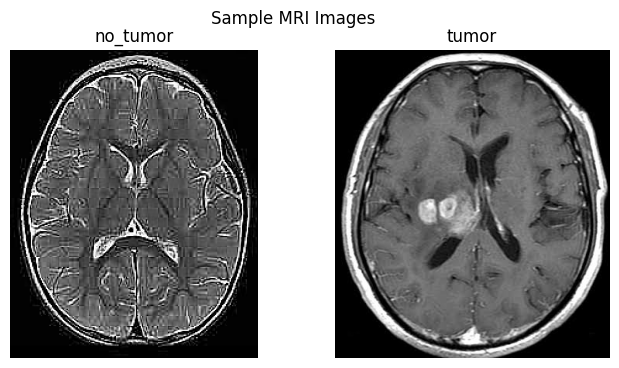

In [8]:
plt.figure(figsize=(8,4))

for i, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    img_name = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_name))

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.suptitle("Sample MRI Images")
plt.show()

In [9]:
def load_images(path, size=(64,64)):
    X, y = [], []
    classes = ["no_tumor", "tumor"]

    for label, cls in enumerate(classes):
        folder = os.path.join(path, cls)

        for file in os.listdir(folder):
            img = Image.open(os.path.join(folder,file)).convert('L')
            img = img.resize(size)
            img = np.array(img).flatten() / 255.0  # NORMALIZATION

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)

X, y = load_images(dataset_path)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (3000, 4096)
Label vector shape: (3000,)


In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

# train val test = 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Print dataset sizes
print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

# Print class distributions
print("Train distribution:", np.bincount(y_train))
print("Validation distribution:", np.bincount(y_val))
print("Test distribution:", np.bincount(y_test))

Train samples: 2100
Validation samples: 450
Test samples: 450
Train distribution: [1050 1050]
Validation distribution: [225 225]
Test distribution: [225 225]


In [11]:
import numpy as np

def augment_data(X, y):
    noise = np.random.normal(0, 0.03, X.shape)
    X_aug = X + noise
    X_aug = np.clip(X_aug, 0, 1)   # IMPORTANT
    return np.vstack([X, X_aug]), np.hstack([y, y])

X_train_aug, y_train_aug = augment_data(X_train, y_train)

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_aug)   # USE AUGMENTED DATA
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

#  update labels
y_train = y_train_aug

# pca
pca = PCA(n_components=150)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

from sklearn.preprocessing import StandardScaler

post_scaler = StandardScaler()

X_train_pca = post_scaler.fit_transform(X_train_pca)
X_val_pca   = post_scaler.transform(X_val_pca)
X_test_pca  = post_scaler.transform(X_test_pca)


import joblib
joblib.dump(post_scaler, "post_scaler.pkl")

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

print("Scaler and PCA saved successfully.")

print("New feature dimension:", X_train_pca.shape[1])
print("Total variance retained:", sum(pca.explained_variance_ratio_))

Scaler and PCA saved successfully.
New feature dimension: 150
Total variance retained: 0.8799666832577713


In [13]:
print("Train PCA mean:", X_train_pca.mean())
print("Train PCA std:", X_train_pca.std())

Train PCA mean: 2.5940449083305246e-18
Train PCA std: 0.9999999999999998


In [14]:
print("After PCA:")
print("Train shape:", X_train_pca.shape)
print("Validation shape:", X_val_pca.shape)
print("Test shape:", X_test_pca.shape)

After PCA:
Train shape: (4200, 150)
Validation shape: (450, 150)
Test shape: (450, 150)


In [15]:
explained_variance = sum(pca.explained_variance_ratio_)
print(f"Total variance retained: {explained_variance:.4f}")

Total variance retained: 0.8800


In [16]:
import torch

# Convert PCA output to tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_pca, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_pca, dtype=torch.float32)

# Labels (important: shape [N,1])
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Train tensor shape:", X_train_t.shape)
print("Label tensor shape:", y_train_t.shape)

Train tensor shape: torch.Size([4200, 150])
Label tensor shape: torch.Size([4200, 1])


In [17]:
print(type(X_train_pca))
print(type(X_train_t))

<class 'numpy.ndarray'>
<class 'torch.Tensor'>


In [18]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 132
Validation batches: 15
Test batches: 15


In [19]:
INPUT_DIM = X_train_pca.shape[1]
FEATURE_DIM = 8

class FCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(INPUT_DIM, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, FEATURE_DIM),

        )

        self.classifier = nn.Linear(FEATURE_DIM, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

In [20]:
# Add at the end of Part 1 (after cells[19]):
torch.save(X_train_t, "X_train_t.pt")
torch.save(X_val_t,   "X_val_t.pt")
torch.save(X_test_t,  "X_test_t.pt")
torch.save(y_train_t, "y_train_t.pt")
torch.save(y_val_t,   "y_val_t.pt")
torch.save(y_test_t,  "y_test_t.pt")

In [21]:
model = FCNN()

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0]))

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 5e-5,
    weight_decay=2e-3   # Slightly stronger regularization
)

In [22]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float("inf")
patience = 5
counter = 0

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            total_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss/len(loader), correct/total


for epoch in range(30):

    model.train()
    total_train_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_train_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1 | Train Loss: 0.6943 | Val Loss: 0.6943 | Train Acc: 0.4988 | Val Acc: 0.5000
Epoch 2 | Train Loss: 0.6919 | Val Loss: 0.6908 | Train Acc: 0.5036 | Val Acc: 0.4978
Epoch 3 | Train Loss: 0.6873 | Val Loss: 0.6870 | Train Acc: 0.5114 | Val Acc: 0.4978
Epoch 4 | Train Loss: 0.6839 | Val Loss: 0.6827 | Train Acc: 0.5195 | Val Acc: 0.5022
Epoch 5 | Train Loss: 0.6781 | Val Loss: 0.6758 | Train Acc: 0.5552 | Val Acc: 0.5622
Epoch 6 | Train Loss: 0.6697 | Val Loss: 0.6670 | Train Acc: 0.5840 | Val Acc: 0.5956
Epoch 7 | Train Loss: 0.6573 | Val Loss: 0.6531 | Train Acc: 0.6452 | Val Acc: 0.6689
Epoch 8 | Train Loss: 0.6389 | Val Loss: 0.6335 | Train Acc: 0.6995 | Val Acc: 0.7422
Epoch 9 | Train Loss: 0.6147 | Val Loss: 0.6050 | Train Acc: 0.7393 | Val Acc: 0.8133
Epoch 10 | Train Loss: 0.5797 | Val Loss: 0.5702 | Train Acc: 0.7862 | Val Acc: 0.8600
Epoch 11 | Train Loss: 0.5347 | Val Loss: 0.5219 | Train Acc: 0.8055 | Val Acc: 0.8556
Epoch 12 | Train Loss: 0.4932 | Val Loss: 0.4723 | T

In [23]:
model = FCNN()
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

FCNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[205  20]
 [ 10 215]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93       225
         1.0       0.91      0.96      0.93       225

    accuracy                           0.93       450
   macro avg       0.93      0.93      0.93       450
weighted avg       0.93      0.93      0.93       450



In [25]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

FCNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)

In [26]:
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)

        probs = torch.sigmoid(outputs)      # probabilities
        preds = (probs > 0.5).float()       # binary predictions

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

In [27]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9333


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[205  20]
 [ 10 215]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93       225
         1.0       0.91      0.96      0.93       225

    accuracy                           0.93       450
   macro avg       0.93      0.93      0.93       450
weighted avg       0.93      0.93      0.93       450



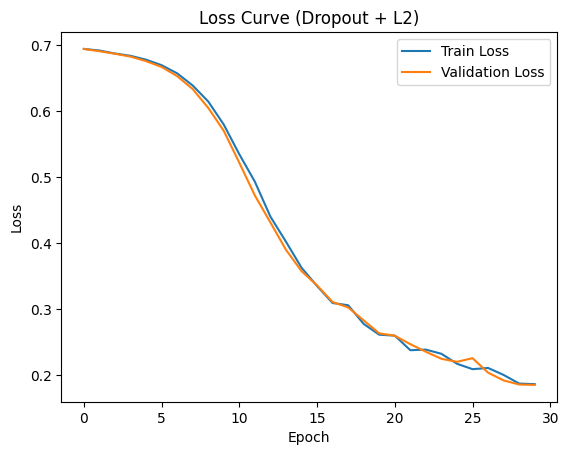

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (Dropout + L2)")
plt.show()

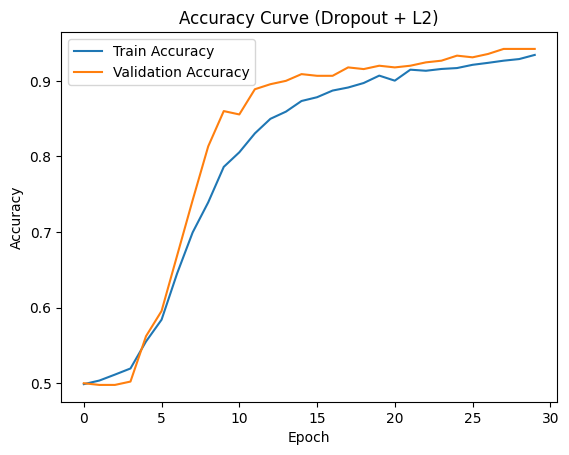

In [30]:
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve (Dropout + L2)")
plt.show()

In [31]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

FCNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)

In [32]:
def get_accuracy(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return correct / total

In [33]:
train_acc = get_accuracy(train_loader)
val_acc   = get_accuracy(val_loader)
test_acc  = get_accuracy(test_loader)

print(f"Final Train Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Train Accuracy: 0.9726
Final Validation Accuracy: 0.9422
Final Test Accuracy: 0.9333


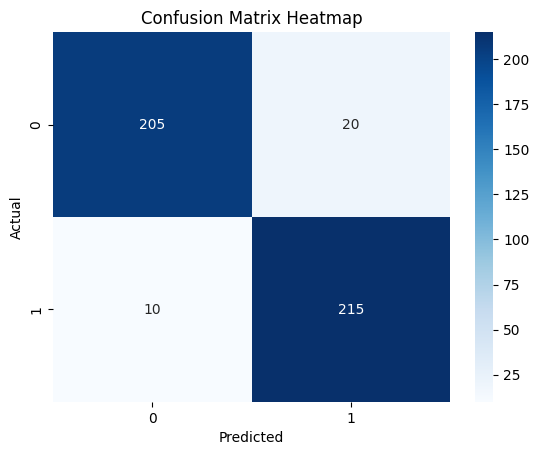

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [35]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

AUC Score: 0.9769


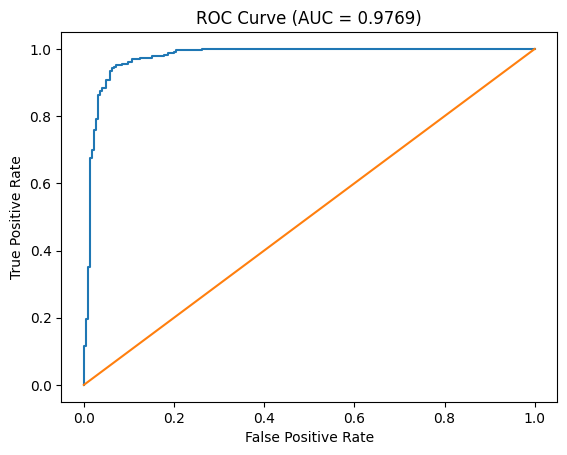

In [36]:
from sklearn.metrics import roc_curve, auc

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.numpy())
        all_labels.extend(yb.numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

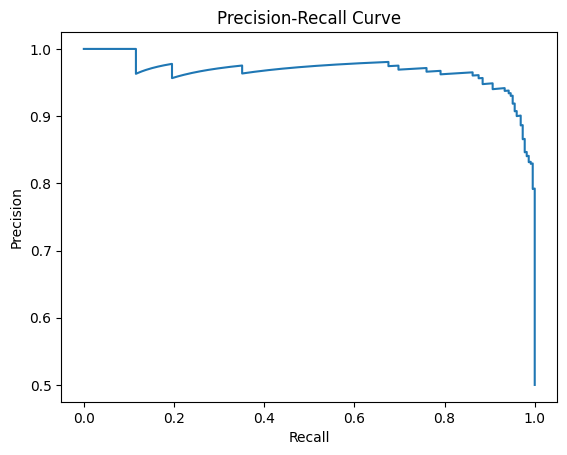

In [37]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [38]:
# Extract features from test set
model.eval()
features_list = []
labels_list = []

with torch.no_grad():
    for xb, yb in test_loader:
        features = model.feature_extractor(xb)
        features_list.extend(features.numpy())
        labels_list.extend(yb.numpy())

features_array = np.array(features_list)
labels_array = np.array(labels_list)

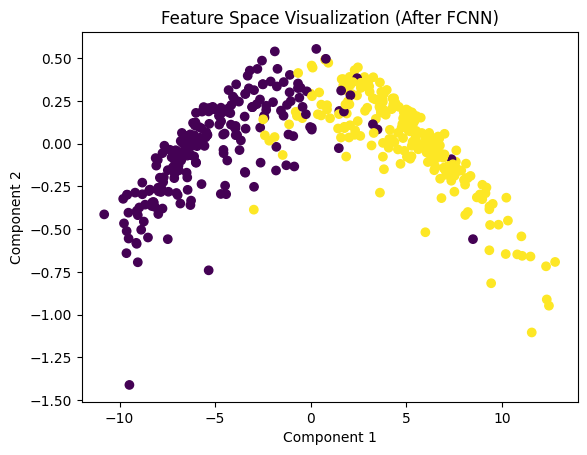

In [39]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)
features_2d = pca_vis.fit_transform(features_array)

plt.figure()
plt.scatter(features_2d[:,0], features_2d[:,1], c=labels_array)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Feature Space Visualization (After FCNN)")
plt.show()

Quantum Machine Learning

In [40]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
)
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pennylane as qml
print("All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"PennyLane version: {qml.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

All imports successful
PyTorch version: 2.10.0+cu128
PennyLane version: 0.44.1
Device: cuda


In [41]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
INPUT_DIM   = 150       # PCA output dimension
FEATURE_DIM = 8         # FCNN feature extractor output / number of qubits
N_QUBITS    = FEATURE_DIM
N_LAYERS    = 6         # Number of variational layers in the VQC
BATCH_SIZE  = 32
LR          = 0.005     # Learning rate for VQC parameters
EPOCHS      = 50
PATIENCE    = 10
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_PATH     = "/content/dataset"       # Path to dataset
PRETRAINED_PATH  = "best_model.pth"         # Pretrained FCNN weights
BEST_VQC_PATH    = "best_vqc_model.pth"     # Where to save best VQC model
print("Configuration set")
print(f"  Qubits:           {N_QUBITS}")
print(f"  VQC layers:       {N_LAYERS}")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"  Learning rate:    {LR}")
print(f"  Max epochs:       {EPOCHS}")
print(f"  Early stopping:   patience={PATIENCE}")

Configuration set
  Qubits:           8
  VQC layers:       6
  Batch size:       32
  Learning rate:    0.005
  Max epochs:       50
  Early stopping:   patience=10


In [42]:
# Replace cells[43]–cells[48] in Part 2 with:
X_train_t = torch.load("X_train_t.pt")
X_val_t   = torch.load("X_val_t.pt")
X_test_t  = torch.load("X_test_t.pt")
y_train_t = torch.load("y_train_t.pt")
y_val_t   = torch.load("y_val_t.pt")
y_test_t  = torch.load("y_test_t.pt")

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),     batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),   batch_size=BATCH_SIZE)

In [43]:
dev = qml.device("default.qubit", wires=N_QUBITS)
@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    VQC for binary classification.
      inputs  : (8,) feature vector from FCNN
      weights : (6, 8, 3) trainable rotation angles
    """
    # Encode classical features as rotation angles on qubits
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    # Variational layers: rotations + CNOT entanglement
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    # Measure qubit 0: output in [-1, 1]
    return qml.expval(qml.PauliZ(0))
print("Quantum circuit defined ")
print(f"  Qubits: {N_QUBITS}")
print(f"  Variational layers: {N_LAYERS}")
print(f"  Trainable params per layer: {N_QUBITS * 3} = {N_QUBITS}×3 rotations")
print(f"  Total VQC params: {N_LAYERS * N_QUBITS * 3}")
# Draw the circuit with dummy inputs
print("\nCircuit diagram:")
dummy_inputs = torch.randn(N_QUBITS)
dummy_weights = torch.randn(N_LAYERS, N_QUBITS, 3)
print(qml.draw(quantum_circuit)(dummy_inputs, dummy_weights))

Quantum circuit defined 
  Qubits: 8
  Variational layers: 6
  Trainable params per layer: 24 = 8×3 rotations
  Total VQC params: 144

Circuit diagram:
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
3: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
4: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
5: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
6: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
7: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
tensor([ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229, -0.1863,  2.2082, -0.6380])
M1 = 
tensor([[[ 1.6423e+00, -1.5960e-01, -4.9740e-01],
         [ 4.3959e-01, -7.5813e-01,  1.0783e+00],
         [ 8.0080e-01,  1.6806e+00,  1.2791e+00],
         [ 1.2964e+00,  6.1047e-01,  1.3347e+00],
         [-2.3162e-01,  4.1759e-02, -2.5158e-01],
         [ 8.598

### Explanation of the VQC Code:

1.  **`dev = qml.device("default.qubit", wires=N_QUBITS)`**:
    *   This line initializes a PennyLane quantum device. `default.qubit` is a local simulator, and `wires=N_QUBITS` specifies the number of qubits for the circuit (which is `8` as defined in your configuration).

2.  **`@qml.qnode(dev, interface="torch", diff_method="backprop")`**:
    *   This decorator transforms the `quantum_circuit` function into a QNode, making it compatible with PyTorch for automatic differentiation. `dev` is the quantum device, `interface="torch"` integrates it with PyTorch, and `diff_method="backprop"` enables backpropagation for gradient calculations.

3.  **`def quantum_circuit(inputs, weights):`**:
    *   This function defines the quantum circuit itself. It takes `inputs` (classical features from the FCNN) and `weights` (trainable parameters for the quantum gates) as arguments.

4.  **`qml.AngleEmbedding(inputs, wires=range(N_QUBITS))`**:
    *   This is the feature encoding layer. It maps the classical input features into the quantum state by applying rotation gates (specifically, `Rx` gates by default) to each qubit, where the rotation angles are directly derived from the `inputs` vector.

5.  **`qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))`**:
    *   This is the variational part of the circuit, consisting of multiple layers. Each layer applies a sequence of rotation gates and controlled-NOT (CNOT) gates to entangle the qubits. The `weights` parameter determines the rotation angles within these layers, which are optimized during training. You have `N_LAYERS = 6` such layers.

6.  **`return qml.expval(qml.PauliZ(0))`**:
    *   This line specifies the measurement. `qml.expval(qml.PauliZ(0))` measures the expectation value of the Pauli-Z operator on the first qubit (qubit 0). This expectation value will be a real number between -1 and 1, which is then used as the output for binary classification (remapped to [0, 1] before being passed to `BCELoss` in the hybrid model).

/tmp/ipykernel_3305/2114803803.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


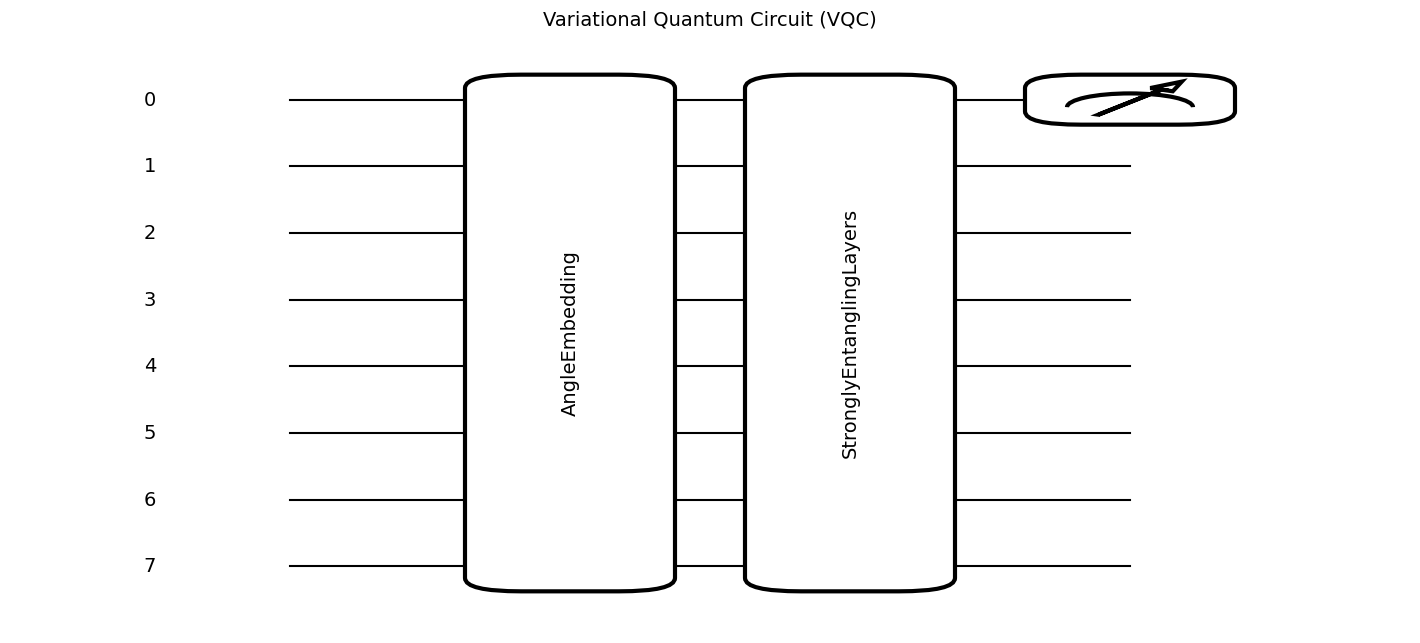

Saved - vqc_circuit_diagram.png


In [44]:
fig, ax = qml.draw_mpl(quantum_circuit)(dummy_inputs, dummy_weights)
fig.set_size_inches(14, 6)
ax.set_title("Variational Quantum Circuit (VQC)", fontsize=14)
plt.tight_layout()
plt.savefig("vqc_circuit_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved - vqc_circuit_diagram.png")

/tmp/ipykernel_3305/3704323341.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


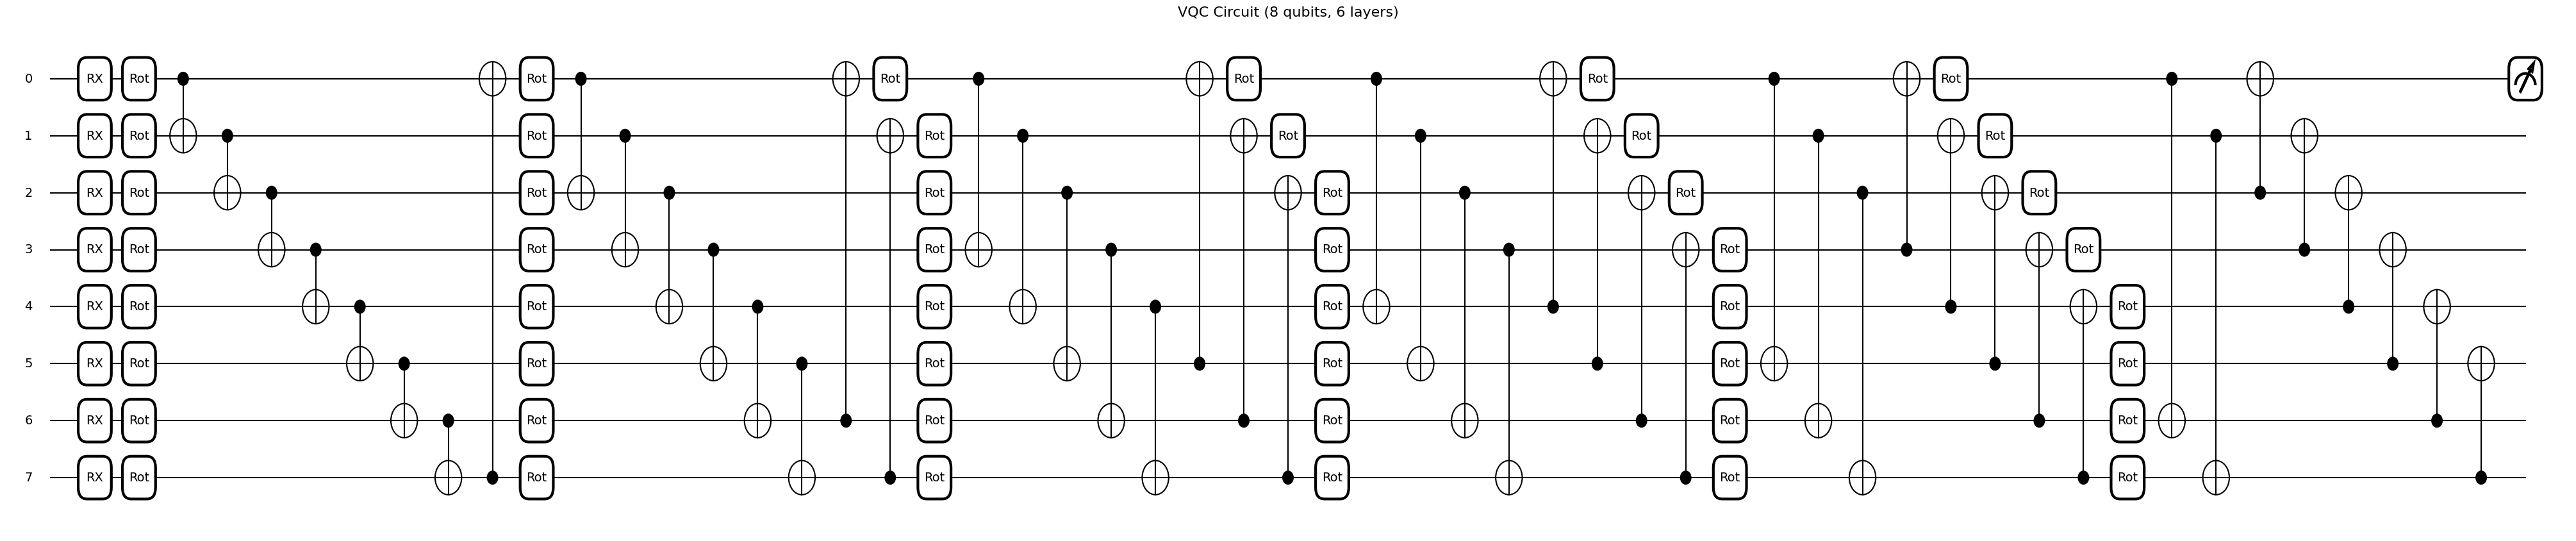

Saved - vqc_circuit_full_expanded.png


In [45]:
fig3, ax3 = qml.draw_mpl(quantum_circuit, level="device")(dummy_inputs, dummy_weights)
fig3.set_size_inches(40, 8)
ax3.set_title("VQC Circuit (8 qubits, 6 layers)", fontsize=16)
plt.tight_layout()
plt.savefig("vqc_circuit_full_expanded.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved - vqc_circuit_full_expanded.png")

/tmp/ipykernel_3305/605272023.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


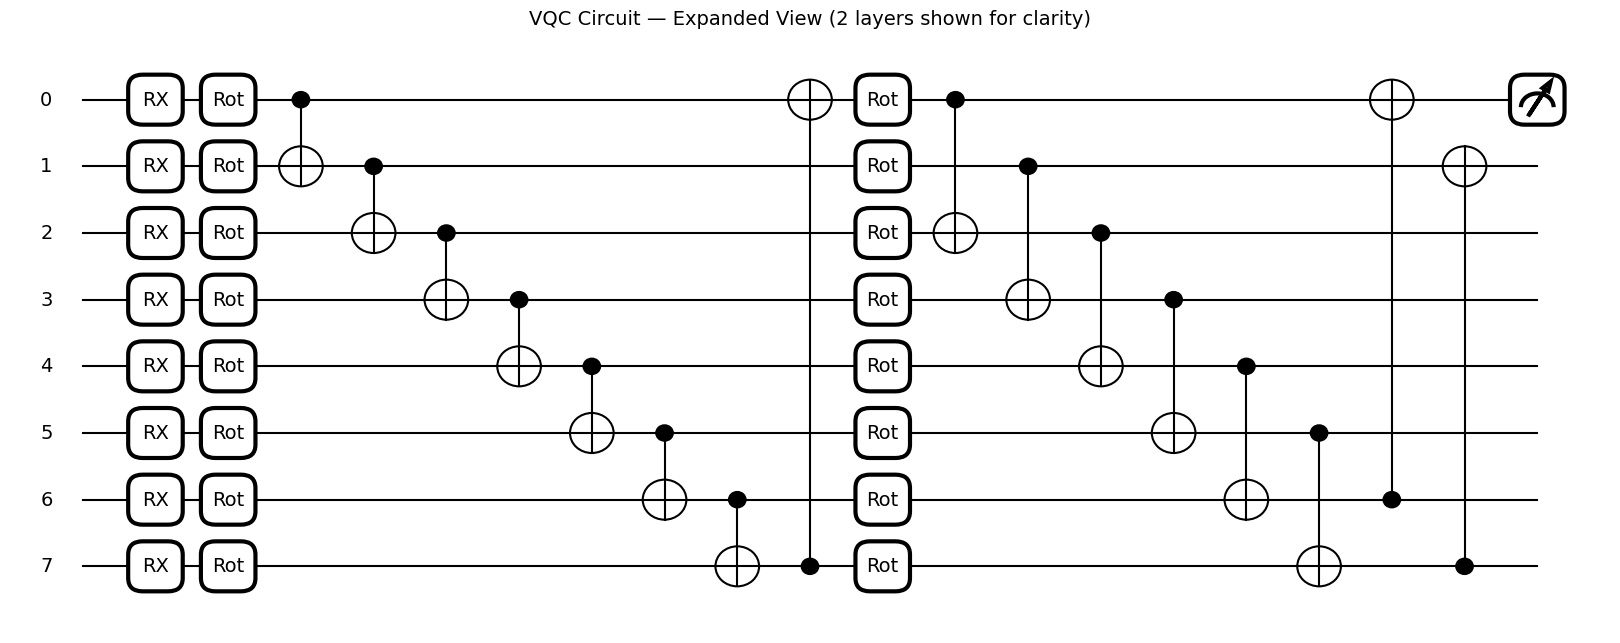

Saved - vqc_circuit_expanded.png


In [46]:
dev_small = qml.device("default.qubit", wires=N_QUBITS)
@qml.qnode(dev_small, interface="torch")
def small_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))
small_weights = torch.randn(2, N_QUBITS, 3)  # only 2 layers
fig2, ax2 = qml.draw_mpl(small_circuit, level="device")(dummy_inputs, small_weights)
fig2.set_size_inches(16, 6)
ax2.set_title("VQC Circuit — Expanded View (2 layers shown for clarity)", fontsize=14)
plt.tight_layout()
plt.savefig("vqc_circuit_expanded.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved - vqc_circuit_expanded.png")

In [47]:
from google.colab import files
files.download("vqc_circuit_diagram.png")
files.download("vqc_circuit_full_expanded.png")
files.download("vqc_circuit_expanded.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(INPUT_DIM, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, FEATURE_DIM),
        )
        self.classifier = nn.Linear(FEATURE_DIM, 1)
    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

fcnn = FCNN()
fcnn.load_state_dict(torch.load(PRETRAINED_PATH, map_location=DEVICE))
fcnn.eval()
print("Pretrained FCNN loaded ")

Pretrained FCNN loaded 


In [49]:
class FCNN_VQC(nn.Module):
    """
    Hybrid model:
      FCNN feature_extractor - adapter - VQC classifier
    The adapter (Linear + Tanh * π) maps unbounded ReLU outputs
    to [-π, π], which is the ideal range for AngleEmbedding.
    """
    def __init__(self, pretrained_fcnn):
        super().__init__()
        # Reuse feature extractor (fine-tuned with a small lr)
        self.feature_extractor = pretrained_fcnn.feature_extractor
        # Adapter: maps ReLU outputs to [-π, π] for angle encoding
        self.adapter = nn.Sequential(
            nn.Linear(FEATURE_DIM, FEATURE_DIM),
            nn.Tanh(),                            # output in [-1, 1]
        )
        # VQC as classifier (replaces nn.Linear(8, 1))
        weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
        self.vqc = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
    def forward(self, x):
        # Extract features
        features = self.feature_extractor(x)
        # Adapter: scale to [-π, π] for angle embedding
        features = self.adapter(features) * np.pi
        # VQC output in [-1, 1]
        out = self.vqc(features)
        # Remap to [0, 1] for BCELoss
        out = (out + 1.0) / 2.0
        return out.unsqueeze(1)   # shape: (batch, 1)
model = FCNN_VQC(fcnn)
model.to(DEVICE)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print("Hybrid FCNN-VQC model built ")
print(model)
print(f"\n  Trainable params (all):  {n_trainable}")
print(f"  Frozen params:           {n_frozen}")
print(f"  Total params:            {n_trainable + n_frozen}")

Hybrid FCNN-VQC model built 
FCNN_VQC(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
  )
  (adapter): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): Tanh()
  )
  (vqc): <Quantum Torch Layer: func=quantum_circuit>
)

  Trainable params (all):  12352
  Frozen params:           0
  Total params:            12352


In [50]:
criterion = nn.BCELoss()
# Differential learning rates:
# FCNN feature extractor: small lr (fine-tune gently)
# Adapter + VQC : larger lr (needs to learn from scratch)
optimizer = optim.Adam([
    {"params": model.feature_extractor.parameters(), "lr": 5e-5},
    {"params": model.adapter.parameters(),           "lr": 0.01,  "weight_decay": 1e-4},
    {"params": model.vqc.parameters(),               "lr": 0.01,  "weight_decay": 1e-4},
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss = float("inf")
counter = 0
print("Starting training...\n")
for epoch in range(1, EPOCHS + 1):
    #  Train
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == yb).sum().item()
        total   += yb.size(0)
    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total
    #  Validate
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total   = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_running_loss += loss.item()
            preds = (outputs > 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_total   += yb.size(0)
    val_loss = val_running_loss / len(val_loader)
    val_acc  = val_correct / val_total
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(
        f"Epoch {epoch:2d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
    )
    #  Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), BEST_VQC_PATH)
        print(f"    Best model saved (val_loss={val_loss:.4f})")
    else:
        counter += 1
        print(f"    No improvement ({counter}/{PATIENCE})")
    scheduler.step()
    if counter >= PATIENCE:
        print("\nEarly stopping triggered!")
        break
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Starting training...

Epoch  1/50 | Train Loss: 0.3590 | Val Loss: 0.1894 | Train Acc: 0.9181 | Val Acc: 0.9444
    Best model saved (val_loss=0.1894)
Epoch  2/50 | Train Loss: 0.1940 | Val Loss: 0.1704 | Train Acc: 0.9324 | Val Acc: 0.9467
    Best model saved (val_loss=0.1704)
Epoch  3/50 | Train Loss: 0.1879 | Val Loss: 0.1640 | Train Acc: 0.9305 | Val Acc: 0.9467
    Best model saved (val_loss=0.1640)
Epoch  4/50 | Train Loss: 0.1753 | Val Loss: 0.1568 | Train Acc: 0.9386 | Val Acc: 0.9467
    Best model saved (val_loss=0.1568)
Epoch  5/50 | Train Loss: 0.1812 | Val Loss: 0.1545 | Train Acc: 0.9379 | Val Acc: 0.9511
    Best model saved (val_loss=0.1545)
Epoch  6/50 | Train Loss: 0.1749 | Val Loss: 0.1593 | Train Acc: 0.9369 | Val Acc: 0.9533
    No improvement (1/10)
Epoch  7/50 | Train Loss: 0.1777 | Val Loss: 0.1501 | Train Acc: 0.9421 | Val Acc: 0.9489
    Best model saved (val_loss=0.1501)
Epoch  8/50 | Train Loss: 0.1733 | Val Loss: 0.1372 | Train Acc: 0.9400 | Val Acc: 0.957

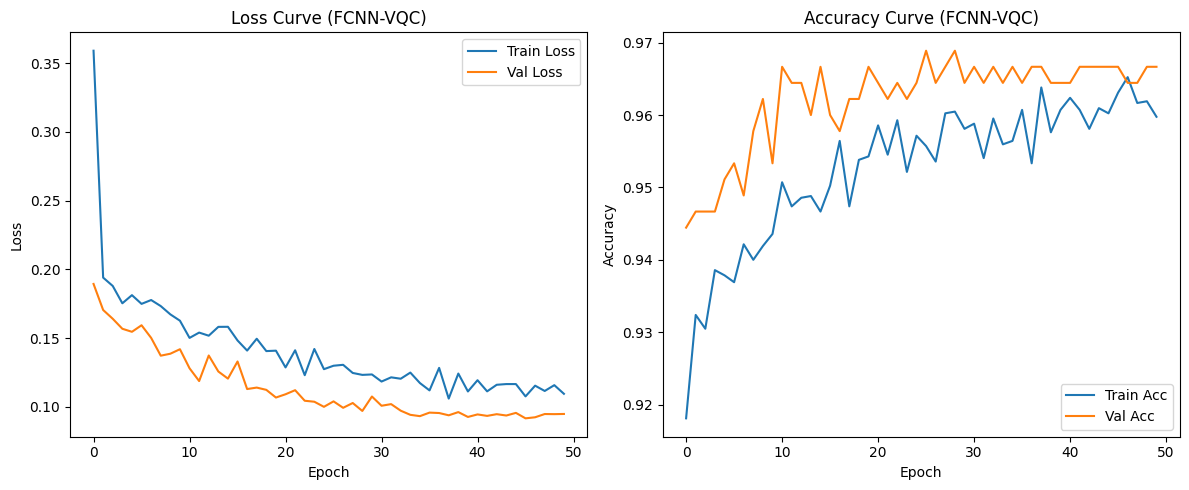

Training curves saved → vqc_training_results.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve (FCNN-VQC)")
axes[0].legend()
axes[1].plot(train_accs, label="Train Acc")
axes[1].plot(val_accs,   label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve (FCNN-VQC)")
axes[1].legend()
plt.tight_layout()
plt.savefig("vqc_training_results.png", dpi=150)
plt.show()
print("Training curves saved → vqc_training_results.png")

In [52]:
model.load_state_dict(torch.load(BEST_VQC_PATH, map_location=DEVICE))
model.eval()
print("Best VQC model loaded")

Best VQC model loaded


In [53]:
all_preds  = []
all_probs  = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        outputs = model(xb)
        probs   = outputs.cpu()
        preds   = (probs > 0.5).float()
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9600


In [54]:
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[209  16]
 [  2 223]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96       225
         1.0       0.93      0.99      0.96       225

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



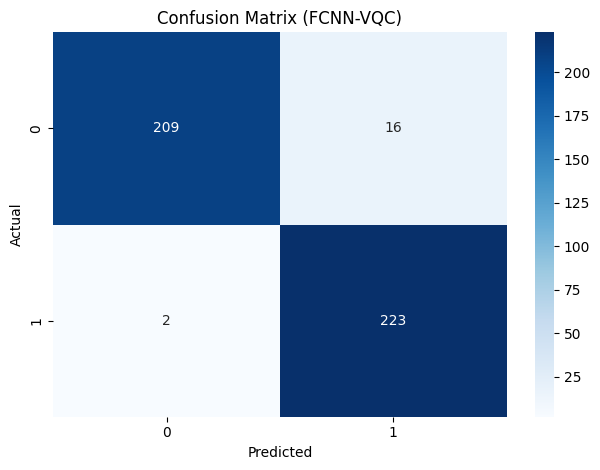

Saved - vqc_confusion_matrix.png


In [55]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (FCNN-VQC)")
plt.tight_layout()
plt.savefig("vqc_confusion_matrix.png", dpi=150)
plt.show()
print("Saved - vqc_confusion_matrix.png")

AUC Score: 0.9871


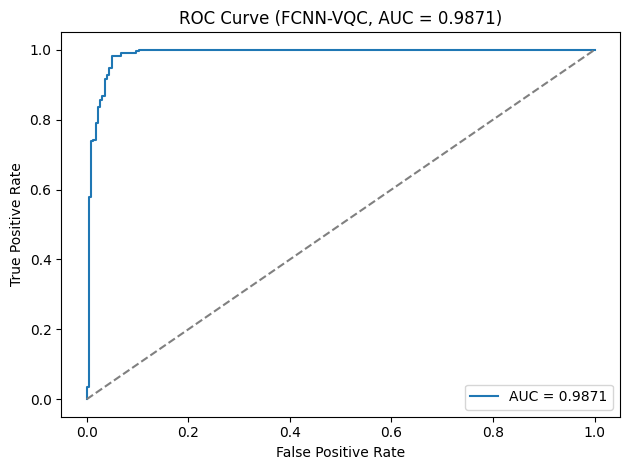

Saved - vqc_roc_curve.png


In [56]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (FCNN-VQC, AUC = {roc_auc:.4f})")
plt.legend()
plt.tight_layout()
plt.savefig("vqc_roc_curve.png", dpi=150)
plt.show()
print("Saved - vqc_roc_curve.png")

Final Accuracy

In [57]:
def get_accuracy(loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            outputs = model(xb)
            preds = (outputs > 0.5).float()
            correct += (preds.cpu() == yb).sum().item()
            total   += yb.size(0)
    return correct / total
train_acc = get_accuracy(train_loader)
val_acc   = get_accuracy(val_loader)
test_acc  = get_accuracy(test_loader)
print(f"Final VQC Train Accuracy:      {train_acc:.4f}")
print(f"Final VQC Validation Accuracy: {val_acc:.4f}")
print(f"Final VQC Test Accuracy:       {test_acc:.4f}")

Final VQC Train Accuracy:      0.9900
Final VQC Validation Accuracy: 0.9667
Final VQC Test Accuracy:       0.9600


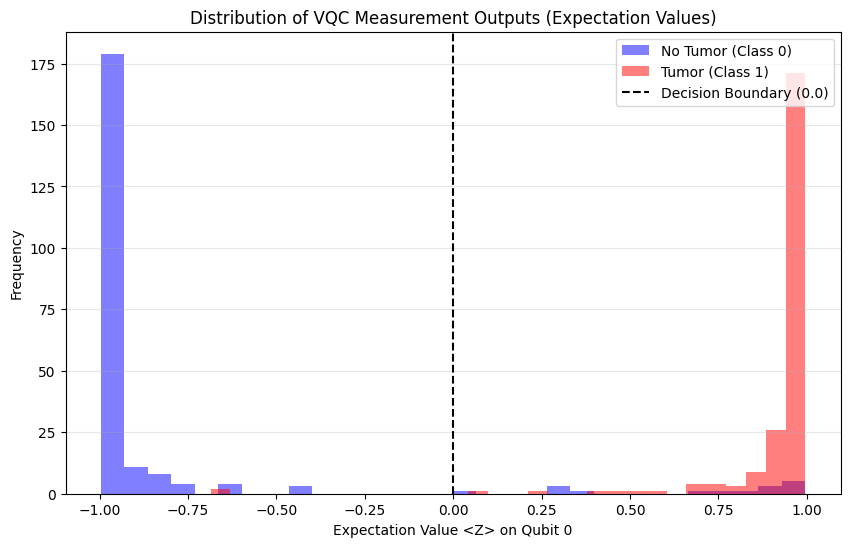

Average <Z> for No Tumor: -0.8365
Average <Z> for Tumor:    0.9243


In [58]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Put model in evaluation mode
model.eval()

# Storage for raw VQC outputs (expectation values in [-1, 1])
no_tumor_vqc = []
tumor_vqc = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        # 1. Extract features
        feat = model.feature_extractor(xb)
        # 2. Map through adapter and scale by pi
        angles = model.adapter(feat) * np.pi
        # 3. Get raw VQC output (expectval is in [-1, 1])
        vqc_out = model.vqc(angles)

        # Convert to CPU/Numpy and sort by label
        vqc_out_np = vqc_out.cpu().numpy()
        yb_np = yb.cpu().numpy().flatten()

        for val, label in zip(vqc_out_np, yb_np):
            if label == 0:
                no_tumor_vqc.append(val)
            else:
                tumor_vqc.append(val)

# Visualization
plt.figure(figsize=(10, 6))
plt.hist(no_tumor_vqc, bins=30, alpha=0.5, label='No Tumor (Class 0)', color='blue')
plt.hist(tumor_vqc, bins=30, alpha=0.5, label='Tumor (Class 1)', color='red')
plt.axvline(x=0, color='black', linestyle='--', label='Decision Boundary (0.0)')
plt.title("Distribution of VQC Measurement Outputs (Expectation Values)")
plt.xlabel("Expectation Value <Z> on Qubit 0")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Average <Z> for No Tumor: {np.mean(no_tumor_vqc):.4f}")
print(f"Average <Z> for Tumor:    {np.mean(tumor_vqc):.4f}")

ROTATION ANGLES FOR A SAMPLE (Class: Tumor)
 Qubit 0  | Radians:  -0.8254 | Degrees:   -47.29°
 Qubit 1  | Radians:  -1.1602 | Degrees:   -66.48°
 Qubit 2  | Radians:  -3.0860 | Degrees:  -176.82°
 Qubit 3  | Radians:   3.0658 | Degrees:   175.66°
 Qubit 4  | Radians:  -2.1076 | Degrees:  -120.76°
 Qubit 5  | Radians:   1.0574 | Degrees:    60.58°
 Qubit 6  | Radians:  -2.7655 | Degrees:  -158.45°
 Qubit 7  | Radians:  -2.0238 | Degrees:  -115.95°


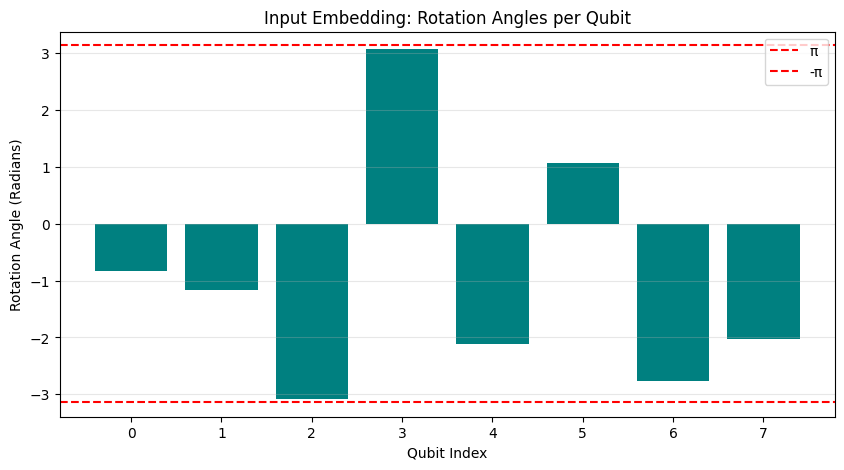

In [59]:
import numpy as np
import torch

# Put model in eval mode
model.eval()

# Pick one test sample from the first batch
xb, yb = next(iter(test_loader))
sample = xb[0:1].to(DEVICE)
label = yb[0].item()

with torch.no_grad():
    #FCNN features
    raw_features = model.feature_extractor(sample)

    #adapter output (Tanh maps to [-1, 1])
    tanh_output = model.adapter(raw_features)

    # Scale by PI to get angles in [-π, π]
    rotation_angles = tanh_output * np.pi

angles_np = rotation_angles.cpu().numpy().flatten()

print("=" * 60)
print(f"ROTATION ANGLES FOR A SAMPLE (Class: {'Tumor' if label==1 else 'No Tumor'})")
print("=" * 60)
for i, angle in enumerate(angles_np):
    deg = np.degrees(angle)
    print(f" Qubit {i}  | Radians: {angle:8.4f} | Degrees: {deg:8.2f}°")

# Visualizing with a bar plot
plt.figure(figsize=(10, 5))
plt.bar(range(N_QUBITS), angles_np, color='teal')
plt.axhline(y=np.pi, color='r', linestyle='--', label='π')
plt.axhline(y=-np.pi, color='r', linestyle='--', label='-π')
plt.xlabel("Qubit Index")
plt.ylabel("Rotation Angle (Radians)")
plt.title("Input Embedding: Rotation Angles per Qubit")
plt.xticks(range(N_QUBITS))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

LEARNED ROTATION ANGLES IN THE VQC ('Rot' Gates)
Total Parameters: 144 (6 layers × 8 qubits × 3 angles)

--- LAYER 1 ---
  Qubit 0: Rz( 0.3686 rad) → Ry( 1.5392 rad) → Rz( 3.1495 rad)
  Qubit 1: Rz( 2.0068 rad) → Ry(-0.4068 rad) → Rz( 1.7715 rad)
  Qubit 2: Rz(-0.1326 rad) → Ry( 4.6690 rad) → Rz( 3.1568 rad)
  Qubit 3: Rz(-0.0274 rad) → Ry( 0.1849 rad) → Rz( 1.7603 rad)
  Qubit 4: Rz( 1.7108 rad) → Ry( 0.5588 rad) → Rz( 3.0111 rad)
  Qubit 5: Rz( 0.1815 rad) → Ry( 1.6744 rad) → Rz( 0.2190 rad)
  Qubit 6: Rz( 4.5911 rad) → Ry( 4.9285 rad) → Rz( 3.1454 rad)
  Qubit 7: Rz(-0.4046 rad) → Ry( 3.0886 rad) → Rz( 2.6763 rad)

--- LAYER 2 ---
  Qubit 0: Rz( 1.5608 rad) → Ry( 1.0426 rad) → Rz( 0.0017 rad)
  Qubit 1: Rz( 1.5592 rad) → Ry( 2.9475 rad) → Rz( 0.0022 rad)
  Qubit 2: Rz( 1.4375 rad) → Ry( 1.4857 rad) → Rz( 1.8253 rad)
  Qubit 3: Rz( 0.2862 rad) → Ry( 0.2511 rad) → Rz( 1.1461 rad)
  Qubit 4: Rz( 0.3588 rad) → Ry( 1.4167 rad) → Rz( 0.1330 rad)
  Qubit 5: Rz( 1.4704 rad) → Ry( 1.5364 rad

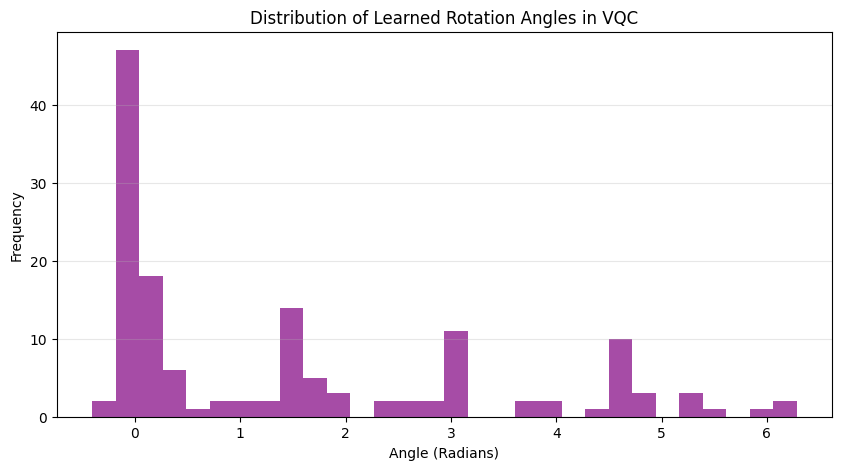

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure model is in eval mode (though weights don't change here)
model.eval()

# The weights are stored in the VQC TorchLayer
# Shape: (N_LAYERS, N_QUBITS, 3)
# The 3 values represent the Rz, Ry, and Rz rotations inside the 'Rot' gate
trained_weights = model.vqc.weights.detach().cpu().numpy()

print("==========================================================")
print("LEARNED ROTATION ANGLES IN THE VQC ('Rot' Gates)")
print("==========================================================")
print(f"Total Parameters: {trained_weights.size} ({N_LAYERS} layers × {N_QUBITS} qubits × 3 angles)\n")

for layer in range(N_LAYERS):
    print(f"--- LAYER {layer + 1} ---")
    for qubit in range(N_QUBITS):
        # Extract the 3 rotation angles for this specific gate
        rz1, ry, rz2 = trained_weights[layer, qubit]

        print(f"  Qubit {qubit}: "
              f"Rz({rz1:7.4f} rad) → "
              f"Ry({ry:7.4f} rad) → "
              f"Rz({rz2:7.4f} rad)")
    print() # blank line between layers

# --- Optional Visualization ---
# Let's visualize the distribution of these weights
plt.figure(figsize=(10, 5))
plt.hist(trained_weights.flatten(), bins=30, color='purple', alpha=0.7)
plt.title("Distribution of Learned Rotation Angles in VQC")
plt.xlabel("Angle (Radians)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()


# **RESULTS AND COMPARISONS**

Recompute FCNN & VQC predictions for comparison

In [61]:
import numpy as np
import torch
import torch.nn as nn
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns

# Reload standalone FCNN
fcnn_eval = FCNN()
fcnn_eval.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
fcnn_eval.eval()
fcnn_eval.to(DEVICE)

# FCNN predictions
fcnn_preds, fcnn_probs, fcnn_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        outputs = fcnn_eval(xb)
        probs = torch.sigmoid(outputs).cpu()
        preds = (probs > 0.5).float()
        fcnn_probs.extend(probs.numpy().flatten())
        fcnn_preds.extend(preds.numpy().flatten())
        fcnn_labels.extend(yb.numpy().flatten())
fcnn_preds  = np.array(fcnn_preds)
fcnn_probs  = np.array(fcnn_probs)
fcnn_labels = np.array(fcnn_labels)

# VQC predictions
model.eval()
vqc_preds, vqc_probs, vqc_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        outputs = model(xb)
        probs = outputs.cpu()
        preds = (probs > 0.5).float()
        vqc_probs.extend(probs.numpy().flatten())
        vqc_preds.extend(preds.numpy().flatten())
        vqc_labels.extend(yb.numpy().flatten())
vqc_preds  = np.array(vqc_preds)
vqc_probs  = np.array(vqc_probs)
vqc_labels = np.array(vqc_labels)

print("✓ Predictions recomputed")
print(f"  FCNN Test Acc: {accuracy_score(fcnn_labels, fcnn_preds):.4f}")
print(f"  VQC  Test Acc: {accuracy_score(vqc_labels, vqc_preds):.4f}")


✓ Predictions recomputed
  FCNN Test Acc: 0.9333
  VQC  Test Acc: 0.9600


Comparative Summary Table

In [62]:
import pandas as pd

def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr_v, tpr_v, _ = roc_curve(y_true, y_prob)
    auc_score = auc(fpr_v, tpr_v)
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Precision":   precision_score(y_true, y_pred),
        "Recall":      recall_score(y_true, y_pred),
        "F1 Score":    f1_score(y_true, y_pred),
        "Specificity": specificity,
        "AUC":         auc_score,
    }

fcnn_m = compute_metrics(fcnn_labels, fcnn_preds, fcnn_probs)
vqc_m  = compute_metrics(vqc_labels, vqc_preds, vqc_probs)

df = pd.DataFrame({
    "Metric": list(fcnn_m.keys()),
    "FCNN": [f"{v:.4f}" for v in fcnn_m.values()],
    "FCNN-VQC": [f"{v:.4f}" for v in vqc_m.values()],
    "Improvement": [f"+{vqc_m[k]-fcnn_m[k]:.4f}" if vqc_m[k]>=fcnn_m[k]
                    else f"{vqc_m[k]-fcnn_m[k]:.4f}" for k in fcnn_m]
})
print("=" * 60)
print("     COMPARATIVE METRICS: FCNN vs FCNN-VQC")
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)


     COMPARATIVE METRICS: FCNN vs FCNN-VQC
     Metric   FCNN FCNN-VQC Improvement
   Accuracy 0.9333   0.9600     +0.0267
  Precision 0.9149   0.9331     +0.0182
     Recall 0.9556   0.9911     +0.0356
   F1 Score 0.9348   0.9612     +0.0264
Specificity 0.9111   0.9289     +0.0178
        AUC 0.9769   0.9871     +0.0102


Side-by-Side Confusion Matrices

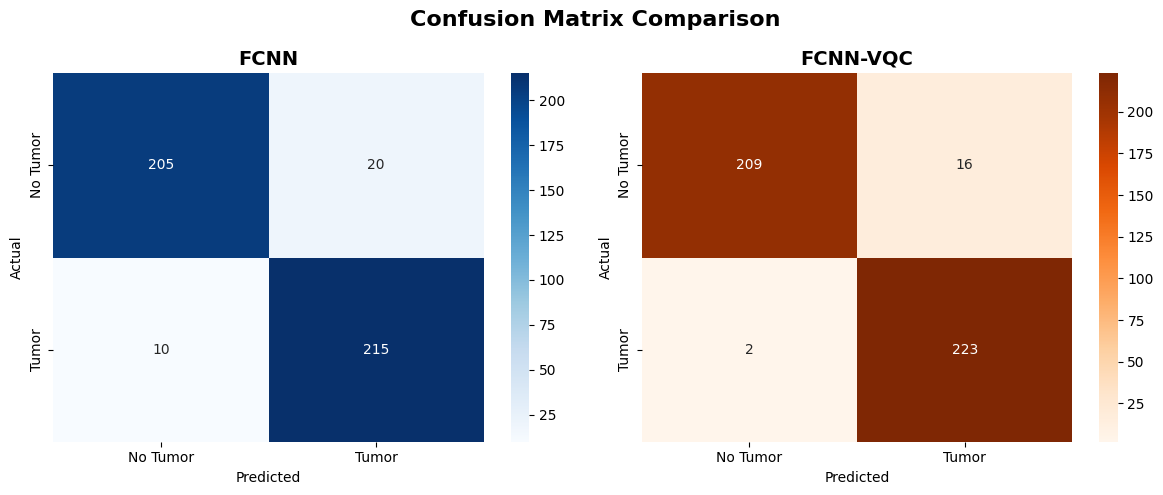

Saved comparison_confusion_matrices.png


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_fcnn = confusion_matrix(fcnn_labels, fcnn_preds)
cm_vqc  = confusion_matrix(vqc_labels, vqc_preds)

sns.heatmap(cm_fcnn, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Tumor","Tumor"], yticklabels=["No Tumor","Tumor"])
axes[0].set_title("FCNN", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_vqc, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=["No Tumor","Tumor"], yticklabels=["No Tumor","Tumor"])
axes[1].set_title("FCNN-VQC", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved comparison_confusion_matrices.png")


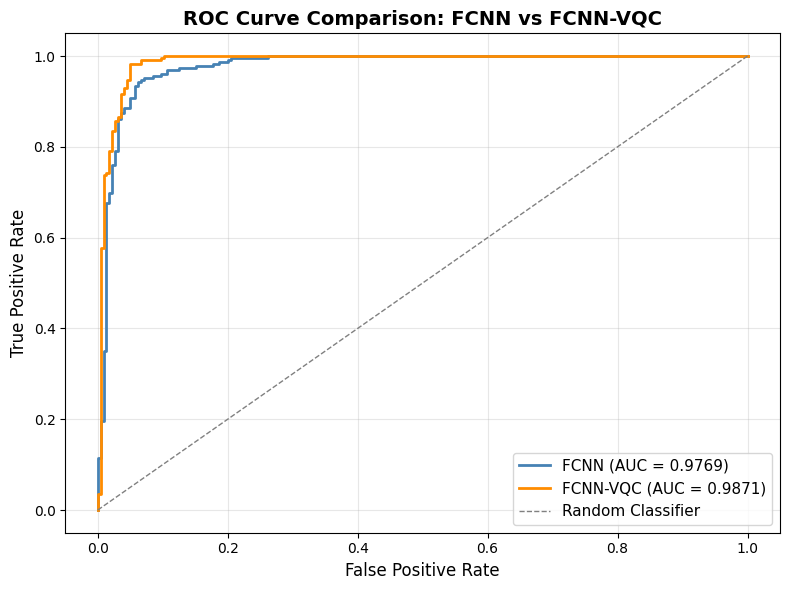

FCNN AUC: 0.9769  |  VQC AUC: 0.9871
Saved → comparison_roc_curves.png


In [65]:
# ─── Overlaid ROC Curves ───
fpr_fcnn, tpr_fcnn, _ = roc_curve(fcnn_labels, fcnn_probs)
auc_fcnn = auc(fpr_fcnn, tpr_fcnn)
fpr_vqc, tpr_vqc, _ = roc_curve(vqc_labels, vqc_probs)
auc_vqc = auc(fpr_vqc, tpr_vqc)

plt.figure(figsize=(8, 6))
plt.plot(fpr_fcnn, tpr_fcnn, label=f"FCNN (AUC = {auc_fcnn:.4f})", linewidth=2, color="steelblue")
plt.plot(fpr_vqc, tpr_vqc, label=f"FCNN-VQC (AUC = {auc_vqc:.4f})", linewidth=2, color="darkorange")
plt.plot([0,1],[0,1], "--", color="gray", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison: FCNN vs FCNN-VQC", fontsize=14, fontweight="bold")
plt.legend(fontsize=11, loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"FCNN AUC: {auc_fcnn:.4f}  |  VQC AUC: {auc_vqc:.4f}")
print("Saved → comparison_roc_curves.png")


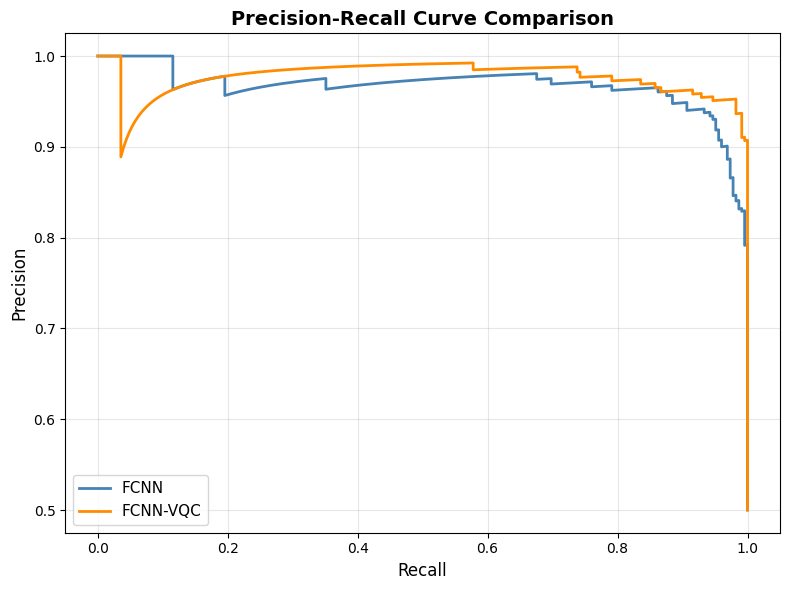

Saved → comparison_pr_curves.png


In [66]:
# ─── Overlaid Precision-Recall Curves ───
prec_fcnn, rec_fcnn, _ = precision_recall_curve(fcnn_labels, fcnn_probs)
prec_vqc,  rec_vqc,  _ = precision_recall_curve(vqc_labels, vqc_probs)

plt.figure(figsize=(8, 6))
plt.plot(rec_fcnn, prec_fcnn, label="FCNN", linewidth=2, color="steelblue")
plt.plot(rec_vqc,  prec_vqc,  label="FCNN-VQC", linewidth=2, color="darkorange")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve Comparison", fontsize=14, fontweight="bold")
plt.legend(fontsize=11, loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_pr_curves.png")


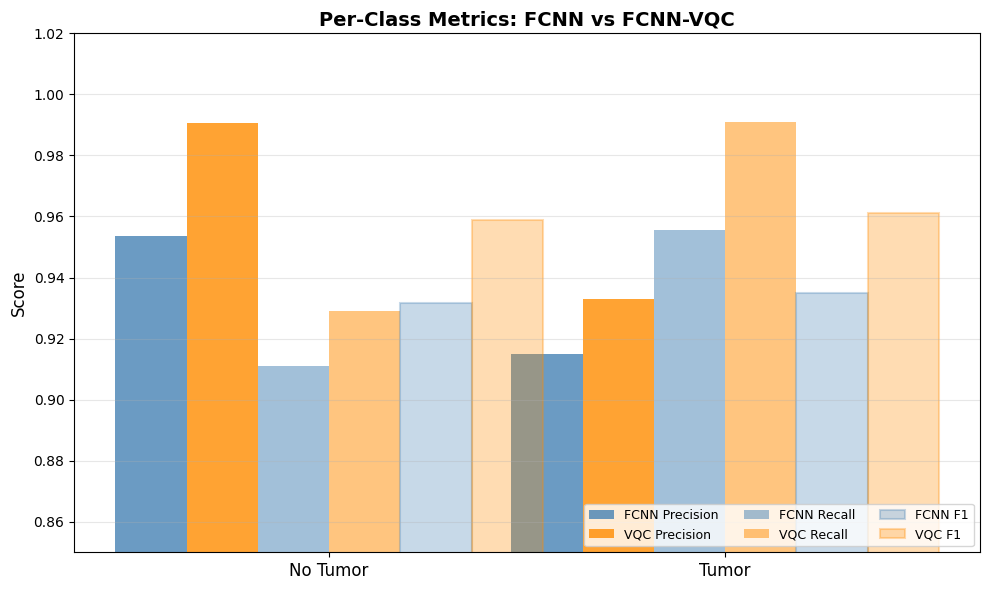

Saved → comparison_per_class_metrics.png


In [67]:
# ─── Per-Class Metrics Bar Chart ───
prec_f, rec_f, f1_f, _ = precision_recall_fscore_support(fcnn_labels, fcnn_preds, average=None)
prec_v, rec_v, f1_v, _ = precision_recall_fscore_support(vqc_labels, vqc_preds, average=None)

classes = ["No Tumor", "Tumor"]
x = np.arange(len(classes))
width = 0.18

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 2.5*width, prec_f, width, label="FCNN Precision", color="steelblue", alpha=0.8)
ax.bar(x - 1.5*width, prec_v, width, label="VQC Precision", color="darkorange", alpha=0.8)
ax.bar(x - 0.5*width, rec_f,  width, label="FCNN Recall", color="steelblue", alpha=0.5)
ax.bar(x + 0.5*width, rec_v,  width, label="VQC Recall", color="darkorange", alpha=0.5)
ax.bar(x + 1.5*width, f1_f,   width, label="FCNN F1", color="steelblue", alpha=0.3, edgecolor="steelblue", linewidth=1.5)
ax.bar(x + 2.5*width, f1_v,   width, label="VQC F1", color="darkorange", alpha=0.3, edgecolor="darkorange", linewidth=1.5)

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Per-Class Metrics: FCNN vs FCNN-VQC", fontsize=14, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(classes, fontsize=12)
ax.legend(fontsize=9, ncol=3, loc="lower right")
ax.set_ylim(0.85, 1.02); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → comparison_per_class_metrics.png")


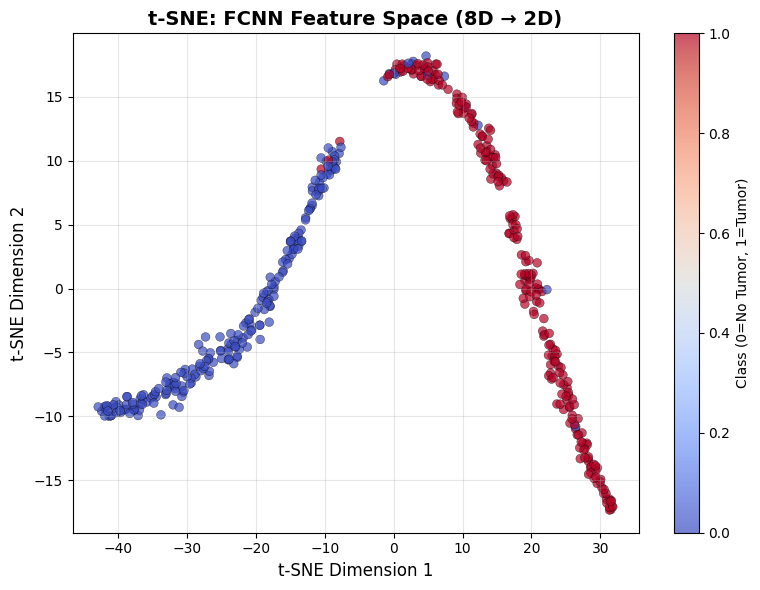

Saved → tsne_feature_space.png


In [68]:
# ─── t-SNE Feature Space Visualization ───
from sklearn.manifold import TSNE

model.eval()
features_list, labels_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        feats = model.feature_extractor(xb).cpu().numpy()
        features_list.extend(feats)
        labels_list.extend(yb.numpy().flatten())

features_arr = np.array(features_list)
labels_arr = np.array(labels_list)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features_arr)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:,0], features_2d[:,1],
                      c=labels_arr, cmap="coolwarm", alpha=0.7,
                      edgecolors="k", linewidths=0.3, s=40)
plt.colorbar(scatter, label="Class (0=No Tumor, 1=Tumor)")
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.title("t-SNE: FCNN Feature Space (8D → 2D)", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("tsne_feature_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tsne_feature_space.png")


In [70]:
# ─── McNemar's Statistical Significance Test ───
from scipy.stats import chi2

fcnn_correct = (fcnn_preds == fcnn_labels)
vqc_correct  = (vqc_preds == vqc_labels)

a = np.sum(fcnn_correct & vqc_correct)     # Both correct
b = np.sum(fcnn_correct & ~vqc_correct)    # FCNN right, VQC wrong
c = np.sum(~fcnn_correct & vqc_correct)    # FCNN wrong, VQC right
d = np.sum(~fcnn_correct & ~vqc_correct)   # Both wrong

print("=" * 50)
print("   McNemar's Test: FCNN vs FCNN-VQC")
print("=" * 50)
print(f"  ┌─────────────────┬──────────┬──────────┐")
print(f"  │                 │ VQC Right│ VQC Wrong│")
print(f"  ├─────────────────┼──────────┼──────────┤")
print(f"  │ FCNN Right      │    {a:4d}  │    {b:4d}  │")
print(f"  │ FCNN Wrong      │    {c:4d}  │    {d:4d}  │")
print(f"  └─────────────────┴──────────┴──────────┘")

if (b + c) > 0:
    chi2_stat = (abs(b - c) - 1)**2 / (b + c)
    p_value = 1 - chi2.cdf(chi2_stat, df=1)
else:
    chi2_stat, p_value = 0, 1.0

print(f"\n  b (FCNN right, VQC wrong): {b}")
print(f"  c (FCNN wrong, VQC right): {c}")
print(f"  Chi² statistic:  {chi2_stat:.4f}")
print(f"  p-value:         {p_value:.4f}")

if p_value < 0.05:
    print(f"\n   STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"\n  ⚠ NOT statistically significant (p ≥ 0.05)")
    print(f"    Consider k-fold cross-validation for a more robust test.")
print("=" * 50)


   McNemar's Test: FCNN vs FCNN-VQC
  ┌─────────────────┬──────────┬──────────┐
  │                 │ VQC Right│ VQC Wrong│
  ├─────────────────┼──────────┼──────────┤
  │ FCNN Right      │     419  │       1  │
  │ FCNN Wrong      │      13  │      17  │
  └─────────────────┴──────────┴──────────┘

  b (FCNN right, VQC wrong): 1
  c (FCNN wrong, VQC right): 13
  Chi² statistic:  8.6429
  p-value:         0.0033

   STATISTICALLY SIGNIFICANT (p < 0.05)


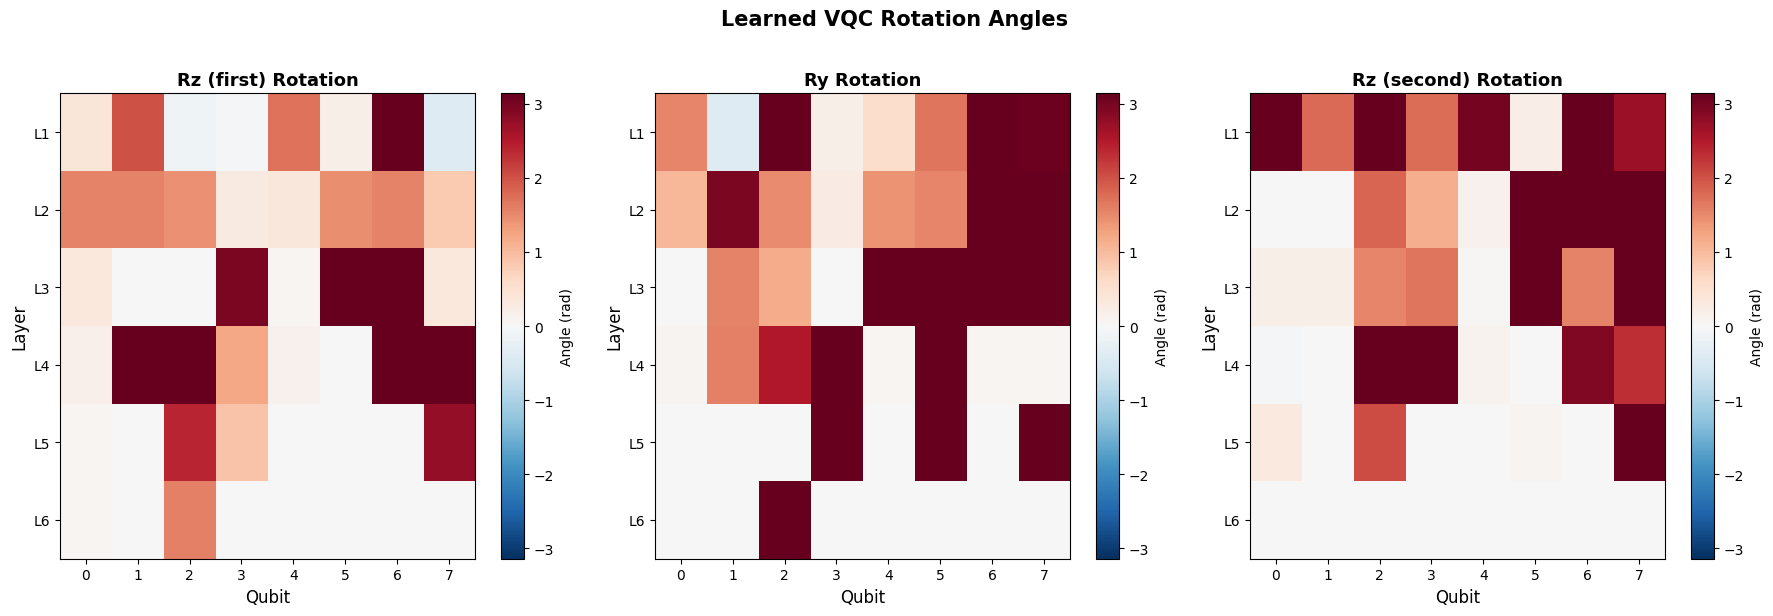

Total VQC params: 144
Mean |rotation|: 1.5196 rad
Saved  vqc_parameter_heatmap.png


In [71]:
# ─── VQC Parameter Heatmap ───
trained_weights = model.vqc.weights.detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rotation_names = ["Rz (first)", "Ry", "Rz (second)"]

for idx, (ax, name) in enumerate(zip(axes, rotation_names)):
    data = trained_weights[:, :, idx]
    im = ax.imshow(data, cmap="RdBu_r", aspect="auto", vmin=-np.pi, vmax=np.pi)
    ax.set_xlabel("Qubit", fontsize=12)
    ax.set_ylabel("Layer", fontsize=12)
    ax.set_title(f"{name} Rotation", fontsize=13, fontweight="bold")
    ax.set_xticks(range(N_QUBITS))
    ax.set_yticks(range(N_LAYERS))
    ax.set_yticklabels([f"L{i+1}" for i in range(N_LAYERS)])
    plt.colorbar(im, ax=ax, label="Angle (rad)")

plt.suptitle("Learned VQC Rotation Angles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("vqc_parameter_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total VQC params: {trained_weights.size}")
print(f"Mean |rotation|: {np.mean(np.abs(trained_weights)):.4f} rad")
print("Saved  vqc_parameter_heatmap.png")


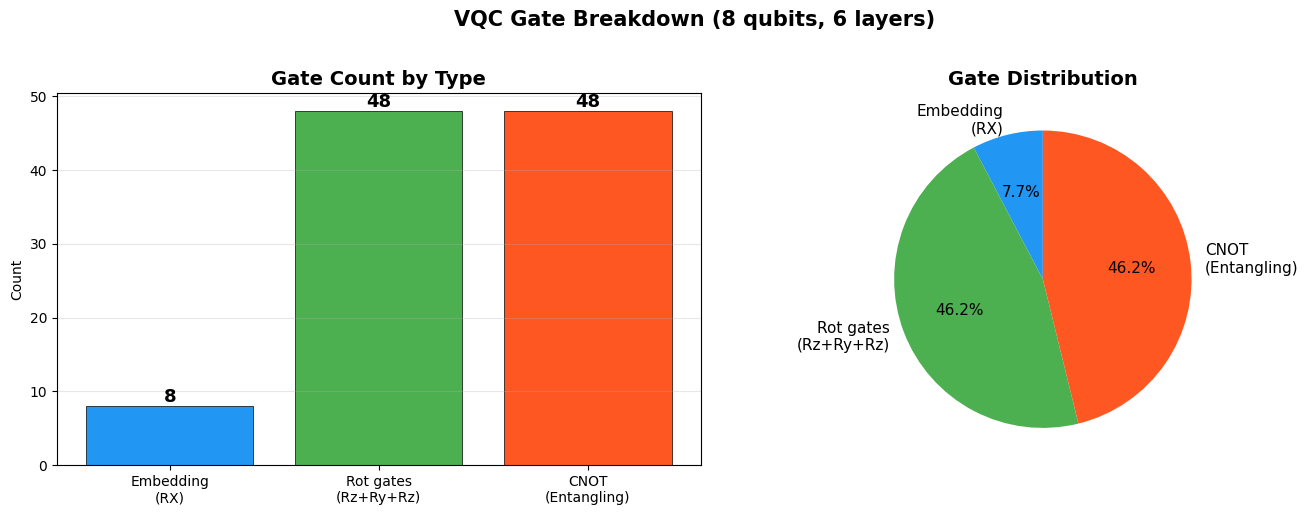

Embedding: 8 | Rot: 48 | CNOT: 48
Saved  vqc_gate_breakdown.png


In [76]:
# ─── Gate Count Breakdown ───
embedding_gates = N_QUBITS
rot_gates = N_LAYERS * N_QUBITS
cnot_gates = N_LAYERS * N_QUBITS

gate_types = ["Embedding\n(RX)", "Rot gates\n(Rz+Ry+Rz)", "CNOT\n(Entangling)"]
gate_counts = [embedding_gates, rot_gates, cnot_gates]
colors = ["#2196F3", "#4CAF50", "#FF5722"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(gate_types, gate_counts, color=colors, edgecolor="black", linewidth=0.5)
for bar, count in zip(bars, gate_counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(count), ha="center", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count"); axes[0].set_title("Gate Count by Type", fontsize=14, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(gate_counts, labels=gate_types, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Gate Distribution", fontsize=14, fontweight="bold")

plt.suptitle(f"VQC Gate Breakdown ({N_QUBITS} qubits, {N_LAYERS} layers)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("vqc_gate_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Embedding: {embedding_gates} | Rot: {rot_gates} | CNOT: {cnot_gates}")
print("Saved  vqc_gate_breakdown.png")


In [73]:
# ─── Model Complexity Comparison ───
fcnn_params = sum(p.numel() for p in fcnn_eval.parameters())
vqc_total   = sum(p.numel() for p in model.parameters())
vqc_quantum = N_LAYERS * N_QUBITS * 3
vqc_classical = vqc_total - vqc_quantum

def measure_time(mdl, loader, use_sigmoid=False):
    mdl.eval()
    times = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            t0 = time.time()
            out = mdl(xb)
            if use_sigmoid: torch.sigmoid(out)
            times.append(time.time() - t0)
    return np.mean(times) * 1000

fcnn_time = measure_time(fcnn_eval, test_loader, use_sigmoid=True)
vqc_time  = measure_time(model, test_loader)

print("=" * 60)
print("        MODEL COMPLEXITY COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'FCNN':>12} {'FCNN-VQC':>12}")
print("-" * 60)
print(f"{'Total Parameters':<30} {fcnn_params:>12,} {vqc_total:>12,}")
print(f"{'  Classical Parameters':<30} {fcnn_params:>12,} {vqc_classical:>12,}")
print(f"{'  Quantum Parameters':<30} {'0':>12} {vqc_quantum:>12,}")
print(f"{'Qubits Used':<30} {'N/A':>12} {N_QUBITS:>12}")
print(f"{'VQC Layers':<30} {'N/A':>12} {N_LAYERS:>12}")
print(f"{'Avg Inference (ms/batch)':<30} {fcnn_time:>12.2f} {vqc_time:>12.2f}")
print(f"{'Test Accuracy':<30} {accuracy_score(fcnn_labels,fcnn_preds):>12.4f} {accuracy_score(vqc_labels,vqc_preds):>12.4f}")
print("=" * 60)


        MODEL COMPLEXITY COMPARISON
Metric                                 FCNN     FCNN-VQC
------------------------------------------------------------
Total Parameters                     12,145       12,352
  Classical Parameters               12,145       12,208
  Quantum Parameters                      0          144
Qubits Used                             N/A            8
VQC Layers                              N/A            6
Avg Inference (ms/batch)               1.45       128.92
Test Accuracy                        0.9333       0.9600


In [75]:
# ─── Empirical Timing Complexity ───
import time

def measure_training_epoch_time(mdl, is_vqc=False):
    mdl.train()
    # Optimizer for this timing test only
    opt = torch.optim.Adam(mdl.parameters(), lr=0.001)
    loss_fn = nn.BCEWithLogitsLoss() if not is_vqc else nn.BCELoss()

    start_time = time.time()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        out = mdl(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        opt.step()

    end_time = time.time()
    return end_time - start_time


# We reload a fresh FCNN so we don't accidentally train our optimized evaluation FCNN
timing_fcnn = FCNN().to(DEVICE)
fcnn_epoch_time = measure_training_epoch_time(timing_fcnn, is_vqc=False)

# By the time this runs, `model` is your trained FCNN-VQC
vqc_epoch_time = measure_training_epoch_time(model, is_vqc=True)

print("=" * 50)
print("    EMPIRICAL TIME COMPLEXITY MEASUREMENTS")
print("=" * 50)
print(f"FCNN Training Time (per epoch):     {fcnn_epoch_time:.2f} seconds")
print(f"FCNN-VQC Training Time (per epoch): {vqc_epoch_time:.2f} seconds")
print("-" * 50)
# Inference time uses the variables generated in Cell 12
print(f"FCNN Inference Time (per batch):    {fcnn_time:.2f} ms")
print(f"FCNN-VQC Inference Time (per batch):{vqc_time:.2f} ms")
print("=" * 50)


    EMPIRICAL TIME COMPLEXITY MEASUREMENTS
FCNN Training Time (per epoch):     0.56 seconds
FCNN-VQC Training Time (per epoch): 28.84 seconds
--------------------------------------------------
FCNN Inference Time (per batch):    1.45 ms
FCNN-VQC Inference Time (per batch):128.92 ms
